# 02 · Reproducible numeric profiling

This notebook profiles a seeded sample drawn from **all available monthly
files**, not only the first one. It analyses both departure and arrival delay,
then restricts the modelling population to scheduled commercial traffic
(`ICAO Flight Type == 'S'`). Physical rules come from the shared configuration.
Distribution transforms are optional and are fitted only on training data.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import PowerTransformer

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.flight_config import (
    DATETIME_FORMAT_PANDAS,
    DataQualityConfig,
    SAMPLE_FRACTION,
    SEED,
    TIME_COLUMNS,
)

REPORTS = PROJECT_ROOT / "reports" / "eda" / "numeric_profiling"
REPORTS.mkdir(parents=True, exist_ok=True)
flight_files = sorted((PROJECT_ROOT / "data" / "raw" / "flights").glob("*.csv.gz"))


## Volume and representative sample


In [2]:
import gzip

row_counts = {}
for path in flight_files:
    with gzip.open(path, "rt", encoding="utf-8") as handle:
        row_counts[path.name] = sum(1 for _ in handle) - 1

display(pd.Series(row_counts, name="rows").to_frame())
print(f"Total rows: {sum(row_counts.values()):,}")


,rows
Flights_20211201_20211231.csv.gz,570200
Flights_20220301_20220331.csv.gz,576258
Flights_20220601_20220630.csv.gz,813452
Flights_20220901_20220930.csv.gz,826994
Flights_20221201_20221231.csv.gz,646840
Flights_20230301_20230331.csv.gz,681919


Total rows: 4,115,663


In [3]:
def sample_all_files(paths, fraction=SAMPLE_FRACTION, seed=SEED, chunksize=100_000):
    # Seeded Bernoulli sample from every file without loading all data at once.
    rng = np.random.default_rng(seed)
    sampled_chunks = []
    for path in paths:
        for chunk in pd.read_csv(path, compression="gzip", chunksize=chunksize):
            mask = rng.random(len(chunk)) < fraction
            sampled_chunks.append(chunk.loc[mask])
    return pd.concat(sampled_chunks, ignore_index=True)


df = sample_all_files(flight_files)
df["source_month"] = pd.to_datetime(
    df["FILED OFF BLOCK TIME"].str[:10], format="%d-%m-%Y", errors="coerce"
).dt.to_period("M").astype("string")

print(f"Sample: {len(df):,} rows × {len(df.columns)} columns")
display(df["source_month"].value_counts(dropna=False).sort_index().to_frame("rows"))


Sample: 617,407 rows × 19 columns


,rows
source_month,
2021-12,85604
2022-03,86243
2022-06,121828
2022-09,124007
2022-12,97363
2023-03,102362


## Missing values and explicit date parsing


In [4]:
text_columns = df.select_dtypes(include="object").columns
df[text_columns] = df[text_columns].apply(lambda series: series.str.strip())
df = df.replace(r"^\s*$", np.nan, regex=True)
df = df.replace(["?", "NA", "NULL", "null", "nan", "None"], np.nan)

missing = pd.DataFrame({
    "nulls": df.isna().sum(),
    "null_pct": (100 * df.isna().mean()).round(3),
}).query("nulls > 0").sort_values("null_pct", ascending=False)
display(missing)

for column in TIME_COLUMNS:
    df[column] = pd.to_datetime(
        df[column], format=DATETIME_FORMAT_PANDAS, errors="coerce"
    )

date_parse_failures = df[list(TIME_COLUMNS)].isna().sum().rename("parse_failures")
display(date_parse_failures.to_frame())


,nulls,null_pct
AC Registration,1223,0.198
ADES Latitude,375,0.061
ADES Longitude,375,0.061
ADEP Latitude,275,0.045
ADEP Longitude,275,0.045
Requested FL,146,0.024


,parse_failures
FILED ARRIVAL TIME,0
ACTUAL ARRIVAL TIME,0
FILED OFF BLOCK TIME,0
ACTUAL OFF BLOCK TIME,0


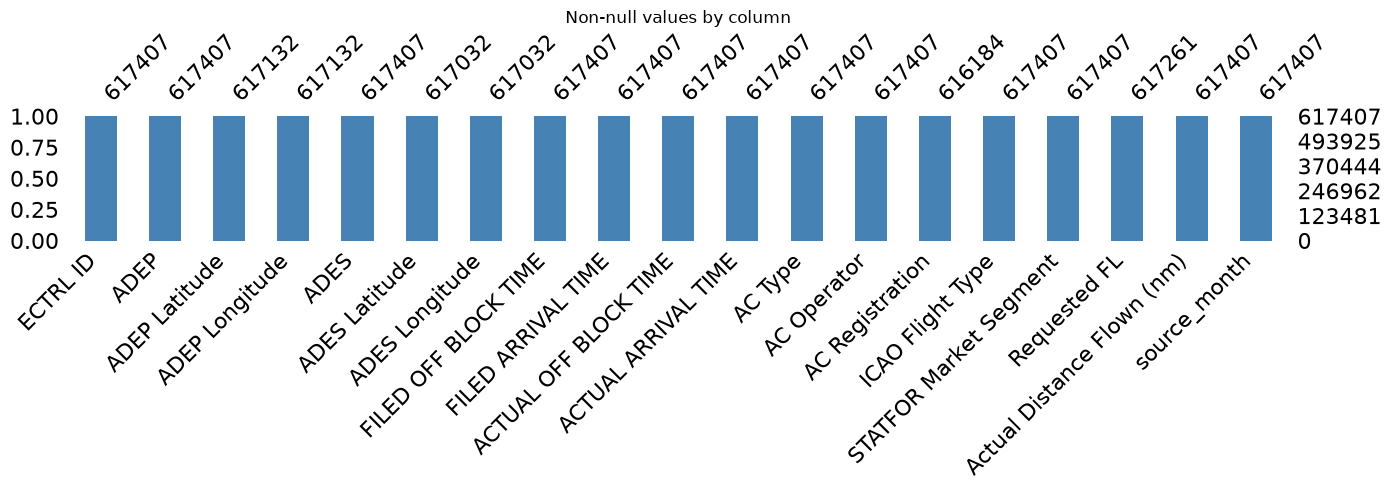

In [5]:
msno.bar(df, color="steelblue", figsize=(14, 5))
plt.title("Non-null values by column")
plt.tight_layout()
plt.savefig(REPORTS / "02_missing_values.png", dpi=300, bbox_inches="tight")
plt.show()


### Missing-data decisions

- `AC Registration`: retain the flight and use `Unknown` only if the feature is
  deliberately included; it is excluded by default because of high cardinality.
- Coordinates: recover from a versioned airport dimension, never a global mean.
- `Requested FL`: fit a median imputer on training data if the model requires it.
- Target or essential timestamp missing: exclude from supervised training and
  report the count.


## Target, physical rules and distributions


In [6]:
df["Arrival_Delay_Min"] = (
    df["ACTUAL ARRIVAL TIME"] - df["FILED ARRIVAL TIME"]
).dt.total_seconds() / 60
df["Departure_Delay_Min"] = (
    df["ACTUAL OFF BLOCK TIME"] - df["FILED OFF BLOCK TIME"]
).dt.total_seconds() / 60

QUALITY = DataQualityConfig(regular_commercial_only=True)

def valid_or_null(series, condition):
    return series.isna() | condition


regular_commercial = df["ICAO Flight Type"].eq(QUALITY.regular_flight_type)
physical_valid = (
    valid_or_null(df["Arrival_Delay_Min"], df["Arrival_Delay_Min"].ge(QUALITY.min_delay_minutes))
    & valid_or_null(df["Departure_Delay_Min"], df["Departure_Delay_Min"].ge(QUALITY.min_delay_minutes))
    & valid_or_null(df["Requested FL"], df["Requested FL"].between(QUALITY.min_flight_level, QUALITY.max_flight_level))
    & valid_or_null(df["Actual Distance Flown (nm)"], df["Actual Distance Flown (nm)"].gt(QUALITY.min_distance_nm))
    & valid_or_null(df["ADEP Latitude"], df["ADEP Latitude"].between(-90, 90))
    & valid_or_null(df["ADES Latitude"], df["ADES Latitude"].between(-90, 90))
    & valid_or_null(df["ADEP Longitude"], df["ADEP Longitude"].between(-180, 180))
    & valid_or_null(df["ADES Longitude"], df["ADES Longitude"].between(-180, 180))
)
valid = regular_commercial & physical_valid

impact = pd.Series({
    "sample_rows": len(df),
    "scheduled_commercial_rows": regular_commercial.sum(),
    "non_regular_rows_excluded": (~regular_commercial).sum(),
    "physical_rule_failures": (~physical_valid).sum(),
    "final_model_rows": valid.sum(),
})
display(impact.to_frame("rows"))
display(df[["Arrival_Delay_Min", "Departure_Delay_Min"]].describe().T)
model_df = df.loc[valid].copy()


,rows
sample_rows,617407
scheduled_commercial_rows,551325
non_regular_rows_excluded,66082
physical_rule_failures,135
final_model_rows,551228


,count,mean,std,min,25%,50%,75%,max
Arrival_Delay_Min,617407.0,4.377003,17.982031,-649.133333,-5.5,2.466667,11.483333,1454.366667
Departure_Delay_Min,617407.0,5.608797,16.378775,-457.833333,-3.5,3.000000,11.000000,639.300000


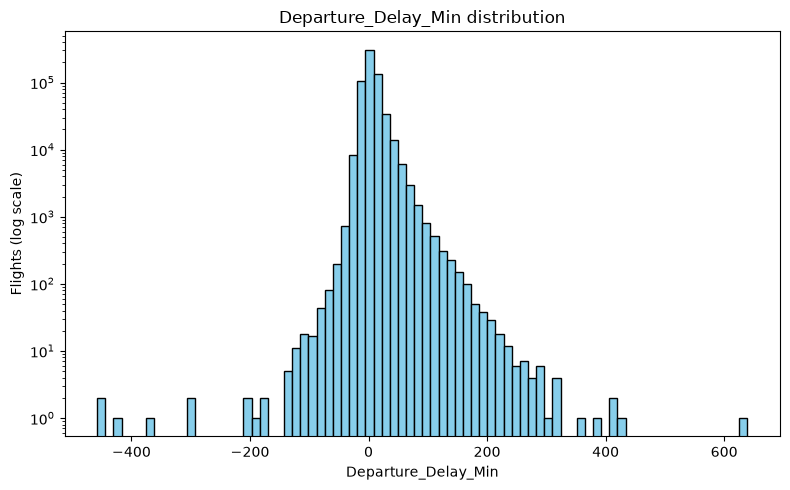

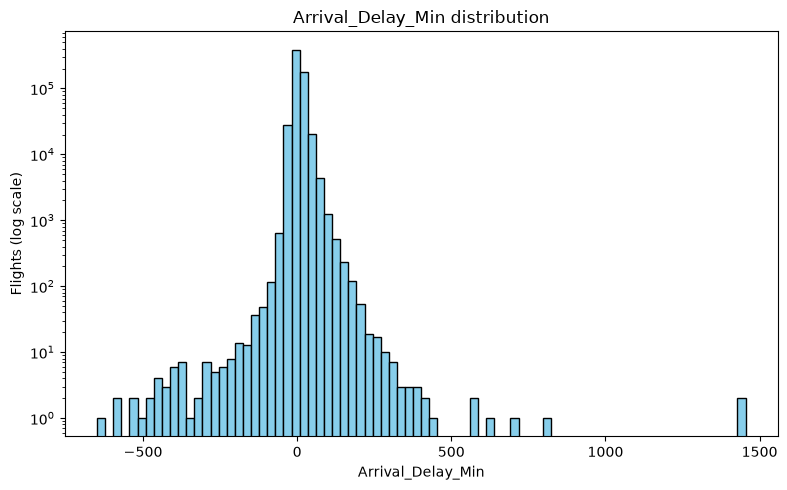

In [7]:
for column, filename in [
    ("Departure_Delay_Min", "02_delay_dep_distribution.png"),
    ("Arrival_Delay_Min", "02_delay_arr_distribution.png"),
]:
    plt.figure(figsize=(8, 5))
    plt.hist(df[column].dropna(), bins=80, log=True, color="skyblue", edgecolor="black")
    plt.xlabel(column)
    plt.ylabel("Flights (log scale)")
    plt.title(f"{column} distribution")
    plt.tight_layout()
    plt.savefig(REPORTS / filename, dpi=300, bbox_inches="tight")
    plt.show()


In [8]:
def outlier_summary(data, columns):
    rows = []
    for column in columns:
        values = data[column].dropna()
        q1, q3 = values.quantile([0.25, 0.75])
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        rows.append({
            "column": column,
            "iqr_low": low,
            "iqr_high": high,
            "iqr_outlier_pct": 100 * ((values < low) | (values > high)).mean(),
            "min": values.min(),
            "max": values.max(),
        })
    return pd.DataFrame(rows).set_index("column")


numeric_features = [
    "ADEP Latitude", "ADEP Longitude", "ADES Latitude", "ADES Longitude",
    "Requested FL", "Actual Distance Flown (nm)",
    "Arrival_Delay_Min", "Departure_Delay_Min",
]
display(outlier_summary(df, numeric_features))


,iqr_low,iqr_high,iqr_outlier_pct,min,max
column,,,,,
ADEP Latitude,23.916380,68.058620,2.804586,-34.857220,78.246110
ADEP Longitude,-29.007905,47.364295,6.771161,-149.998060,151.171670
ADES Latitude,23.381655,68.379455,2.729518,-46.900560,78.246110
ADES Longitude,-29.297495,47.846945,6.872739,-149.998060,168.124440
Requested FL,145.000000,505.000000,5.038063,0.000000,530.000000
Actual Distance Flown (nm),-944.000000,2432.000000,11.284453,0.000000,9545.000000
Arrival_Delay_Min,-30.975000,36.958333,4.420423,-649.133333,1454.366667
Departure_Delay_Min,-25.250000,32.750000,5.547070,-457.833333,639.300000


IQR is descriptive, not a deletion rule. Long-haul distances, locations outside
Europe and large genuine delays are retained. Only impossible domain values or
documented timestamp errors are filtered. Scheduled commercial scope is defined
by `ICAO Flight Type == 'S'`, not by an arbitrary flight-level threshold.
`STATFOR Market Segment` remains a feature because it becomes `Not Classified`
for every flight in the later source periods and is therefore unsafe as a filter.


## Train-only, optional transformations


In [9]:
def fit_optional_numeric_transforms(
    train,
    apply_log=False,
    apply_yeo_johnson=False,
):
    # Fit optional transforms on train and return reusable state.
    state = {"apply_log": apply_log, "apply_yeo_johnson": apply_yeo_johnson}
    if apply_yeo_johnson:
        transformers = {}
        for column in ["Departure_Delay_Min", "Arrival_Delay_Min"]:
            transformer = PowerTransformer(method="yeo-johnson", standardize=False)
            transformer.fit(train[[column]].dropna())
            transformers[column] = transformer
        state["yeo_johnson"] = transformers
    return state


def apply_optional_numeric_transforms(data, state):
    transformed = data.copy()
    if state["apply_log"]:
        transformed["Distance_Log1p"] = np.log1p(
            transformed["Actual Distance Flown (nm)"]
        )
        transformed["Requested_FL_Log1p"] = np.log1p(transformed["Requested FL"])
    if state["apply_yeo_johnson"]:
        for column, transformer in state["yeo_johnson"].items():
            mask = transformed[column].notna()
            transformed.loc[mask, f"{column}_YJ"] = transformer.transform(
                transformed.loc[mask, [column]]
            ).ravel()
    return transformed


validation_start = pd.Timestamp("2022-12-01")
test_start = pd.Timestamp("2023-01-01")
train = model_df[model_df["FILED OFF BLOCK TIME"] < validation_start].copy()
validation = model_df[
    model_df["FILED OFF BLOCK TIME"].between(
        validation_start, test_start, inclusive="left"
    )
].copy()
test = model_df[model_df["FILED OFF BLOCK TIME"] >= test_start].copy()

# Switch these only when the chosen estimator benefits in validation.
transform_state = fit_optional_numeric_transforms(
    train, apply_log=False, apply_yeo_johnson=False
)
train_transformed = apply_optional_numeric_transforms(train, transform_state)
validation_transformed = apply_optional_numeric_transforms(validation, transform_state)
test_transformed = apply_optional_numeric_transforms(test, transform_state)
print({"train": len(train), "validation": len(validation), "test": len(test)})


{'train': 368665, 'validation': 89055, 'test': 93508}


## Correlation, interpreted with feature availability


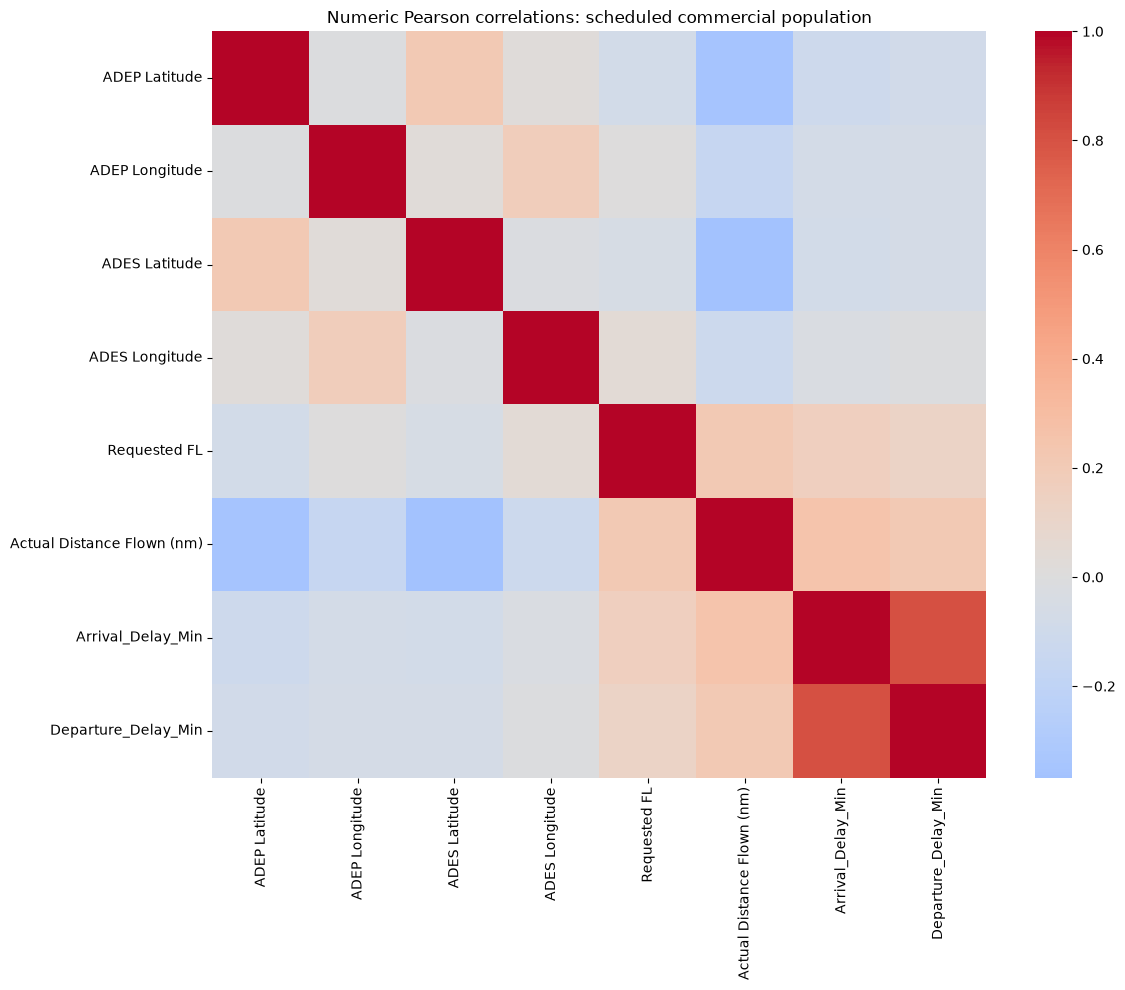

,Departure_Delay_Min
Departure_Delay_Min,1.000000
Arrival_Delay_Min,0.804085
Actual Distance Flown (nm),0.215758
Requested FL,0.121024
ADES Longitude,-0.006867
ADES Latitude,-0.067363
ADEP Longitude,-0.068266
ADEP Latitude,-0.087303


,Arrival_Delay_Min
Arrival_Delay_Min,1.000000
Departure_Delay_Min,0.804085
Actual Distance Flown (nm),0.255301
Requested FL,0.160385
ADES Longitude,-0.028382
ADEP Longitude,-0.072357
ADES Latitude,-0.080575
ADEP Latitude,-0.107752


In [10]:
correlations = model_df.select_dtypes(include=np.number).drop(columns=["ECTRL ID"]).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlations, cmap="coolwarm", center=0)
plt.title("Numeric Pearson correlations: scheduled commercial population")
plt.tight_layout()
plt.savefig(REPORTS / "02_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

for target in ["Departure_Delay_Min", "Arrival_Delay_Min"]:
    display(correlations[target].sort_values(ascending=False).to_frame(target))


## Decisions carried to the pipeline

1. Model both departure and arrival delay before departure.
2. Add a post-off-block update only for arrival delay; departure delay is already
   observed at that point.
3. Restrict the modelling population to `ICAO Flight Type == 'S'`.
4. Train on December 2021–September 2022, validate on December 2022 and reserve
   March 2023 as the untouched final test.
5. Fit every stateful transformation only on train.
6. Do not use actual flown distance before arrival, and use departure delay only
   in the post-off-block arrival task.
7. Compare transformed and untransformed variants; trees usually do not require
   Gaussian inputs.
